In [28]:
#%pip install cerebras_cloud_sdk

In [29]:
import os
from cerebras.cloud.sdk import Cerebras

os.environ['CEREBRAS_API_KEY'] = 'csk-4nryfm65rjdf8e2vrmcx8ch3kw8n5v4wynpdd6e3rwmw9d3k'

client = Cerebras(
    # This is the default and can be omitted
    api_key=os.environ.get("CEREBRAS_API_KEY"),
)

chat_completion = client.chat.completions.create(
    messages=[
        {
            "role": "user",
            "content": "Why is fast inference important?",
        }
],
    model="llama3.1-8b",
)

print(chat_completion)

ChatCompletion(id='chatcmpl-539ca542-819a-4b88-998d-dbcfc8c9e4de', choices=[Choice(finish_reason='stop', index=0, message=ChoiceMessage(role='assistant', content='Fast inference is important for several reasons:\n\n1. **Real-time Decision Making**: In many real-world applications, machine learning models need to make decisions in real-time, such as self-driving cars, robotic process automation, or online recommendation systems. Fast inference enables systems to respond quickly to user inputs or sensory data, ensuring timely and accurate decision-making.\n\n2. **Scalability**: As data volumes increase, models become more complex, and computing resources are limited. Fast inference enables large-scale deployment of models, allowing organizations to handle massive processing tasks in near-real-time.\n\n3. **User Experience**: Faster inference translates to a smoother user experience, particularly in applications with interactive interfaces, such as voice assistants, chatbots, or mobile ap

In [30]:
import http.client

conn = http.client.HTTPSConnection("yahoo-finance15.p.rapidapi.com")

headers = {
    'x-rapidapi-key': "69a7298d19msh6df706df60873e7p11a420jsn3319cdea9e0e",
    'x-rapidapi-host': "yahoo-finance15.p.rapidapi.com"
}

conn.request("GET", "/api/v1/markets/options/most-active?type=STOCKS", headers=headers)

res = conn.getresponse()
data = res.read()

print(data.decode("utf-8"))

{"meta":{"version":"v1.0","status":200,"copywrite":"https:\/\/apicalls.io","count":20,"total":500,"page":1},"body":[{"symbol":"NVDA","symbolType":1,"symbolName":"Nvidia Corp","hasOptions":"Yes","lastPrice":"134.40","priceChange":"-0.03","percentChange":"-0.03%","optionsImpliedVolatilityRank1y":"49.24%","optionsTotalVolume":"1,922,854","optionsPutVolumePercent":"36.5%","optionsCallVolumePercent":"63.5%","optionsPutCallVolumeRatio":"0.57","tradeTime":"13:04 ET","symbolCode":"STK"},{"symbol":"TSLA","symbolType":1,"symbolName":"Tesla Inc","hasOptions":"Yes","lastPrice":"336.96","priceChange":"-0.83","percentChange":"-0.25%","optionsImpliedVolatilityRank1y":"30.74%","optionsTotalVolume":"1,316,598","optionsPutVolumePercent":"46.0%","optionsCallVolumePercent":"54.0%","optionsPutCallVolumeRatio":"0.85","tradeTime":"13:04 ET","symbolCode":"STK"},{"symbol":"PLTR","symbolType":1,"symbolName":"Palantir Technologies Inc Cl A","hasOptions":"Yes","lastPrice":"92.84","priceChange":"-8.51","percentCha

In [31]:
import os
import yfinance as yf
import pandas as pd
from datetime import datetime
import logging
from cerebras.cloud.sdk import Cerebras

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# User-defined settings
date_start = "2022-08-31"  # Start of date range
date_end = "2023-08-31"  # End of date range
tickers = ["ADBE", "AMD", "NFLX"]  # List of tickers to analyze

# Ensure the API key is set in the environment
if 'CEREBRAS_API_KEY' not in os.environ:
    logging.error("CEREBRAS_API_KEY environment variable not set.")
    exit(1)

client = Cerebras(api_key=os.environ.get("CEREBRAS_API_KEY"))

# Function to fetch news data using yfinance
def fetch_news_data(tickers):
    news_data = []
    for ticker_symbol in tickers:
        try:
            ticker = yf.Ticker(ticker_symbol)
            news = ticker.news
            for item in news:
                item['ticker'] = ticker_symbol
                news_data.append(item)
        except Exception as e:
            logging.error(f"{ticker_symbol}: Failed to fetch news data. Error: {e}")
    return news_data

# Function to analyze sentiment using LLaMA API
def analyze_sentiment(text):
    if not text:
        return 0  # Neutral if no valid text

    prompt = f"Analyze the sentiment of the following financial news headline and return a score between -1 (negative) and 1 (positive): '{text}'"
    try:
        response = client.chat.completions.create(
            model="llama3.1-8b",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=10
        )
        sentiment_text = response.choices[0].message.content.strip()
        try:
            sentiment_value = float(sentiment_text)
            return max(-1, min(1, sentiment_value))  # Ensure within range
        except ValueError:
            logging.warning(f"Failed to parse sentiment value: {sentiment_text}")
            return 0  # Default to neutral if parsing fails
    except Exception as e:
        logging.error(f"Failed to analyze sentiment. Error: {e}")
        return 0  # Default to neutral if API call fails

# Fetch news data
news_articles = fetch_news_data(tickers)

# Process and filter by date range and ticker mentions
news_with_sentiment = []
for article in news_articles:
    try:
        date = datetime.utcfromtimestamp(article['providerPublishTime']).strftime('%Y-%m-%d')
        title = article['title']
        ticker = article['ticker']  # Get ticker from the article
        if date_start <= date <= date_end:
            sentiment = analyze_sentiment(title)
            news_with_sentiment.append((date, ticker, sentiment))
    except Exception as e:
        logging.error(f"Failed to process article. Error: {e}")

# Convert to DataFrame and export
if news_with_sentiment:
    sentiment_df = pd.DataFrame(news_with_sentiment, columns=['date', 'ticker', 'sentiment_value'])
    sentiment_df.to_csv("sentiment_analysis.csv", index=False)
    logging.info("Sentiment analysis exported successfully.")
else:
    logging.warning("No valid sentiment data to export.")

2025-02-24 13:43:33,869 - INFO - HTTP Request: GET https://api.cerebras.ai/v1/models "HTTP/1.1 200 OK"
2025-02-24 13:43:34,139 - INFO - HTTP Request: GET https://api.cerebras.ai/v1/models "HTTP/1.1 200 OK"
2025-02-24 13:43:34,660 - INFO - HTTP Request: GET https://api.cerebras.ai/v1/models "HTTP/1.1 200 OK"
2025-02-24 13:43:35,285 - INFO - HTTP Request: GET https://api.cerebras.ai/v1/models "HTTP/1.1 200 OK"
2025-02-24 13:43:35,719 - INFO - HTTP Request: GET https://api.cerebras.ai/v1/models "HTTP/1.1 200 OK"
2025-02-24 13:43:35,723 - ERROR - ADBE: Failed to retrieve the news and received faulty response instead.
2025-02-24 13:43:35,724 - ERROR - AMD: Failed to retrieve the news and received faulty response instead.
2025-02-24 13:43:35,724 - ERROR - NFLX: Failed to retrieve the news and received faulty response instead.
2025-02-24 13:43:35,725 - WARNING - No valid sentiment data to export.


In [ ]:
#pip install textblob

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.3/624.3 kB 963.6 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 1.1 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: nltk
    Found existing installation: nltk 3.8.1
    Uninstalling nltk-3.8.1:
      Successfully uninstalled nltk-3.8.1
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import yfinance as yf
import pandas as pd
from datetime import datetime
import logging
from textblob import TextBlob

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# User-defined settings
date_start = "2022-08-31"  # Start of date range
date_end = "2023-08-31"  # End of date range
tickers = ["ADBE", "AMD", "NFLX"]  # List of tickers to analyze

# Function to fetch news data using yfinance
def fetch_news_data(tickers):
    news_data = []
    for ticker_symbol in tickers:
        try:
            ticker = yf.Ticker(ticker_symbol)
            news = ticker.news
            for item in news:
                item['ticker'] = ticker_symbol
                news_data.append(item)
        except Exception as e:
            logging.error(f"{ticker_symbol}: Failed to fetch news data. Error: {e}")
    return news_data

# Function to analyze sentiment using TextBlob
def analyze_sentiment(text):
    if not text:
        return 0  # Neutral if no valid text

    blob = TextBlob(text)
    return blob.sentiment.polarity  # Returns polarity between -1 (negative) and 1 (positive)

# Fetch news data
news_articles = fetch_news_data(tickers)

# Process and filter by date range and ticker mentions
news_with_sentiment = []
for article in news_articles:
    try:
        date = datetime.utcfromtimestamp(article['providerPublishTime']).strftime('%Y-%m-%d')
        title = article['title']
        ticker = article['ticker']  # Get ticker from the article
        if date_start <= date <= date_end:
            sentiment = analyze_sentiment(title)
            news_with_sentiment.append((date, ticker, sentiment))
    except Exception as e:
        logging.error(f"Failed to process article. Error: {e}")

# Convert to DataFrame and export
if news_with_sentiment:
    sentiment_df = pd.DataFrame(news_with_sentiment, columns=['date', 'ticker', 'sentiment_value'])
    sentiment_df.to_csv("sentiment_analysis_textblob.csv", index=False)
    logging.info("Sentiment analysis exported successfully.")
else:
    logging.warning("No valid sentiment data to export.")

2025-02-24 13:48:20,577 - ERROR - ADBE: Failed to retrieve the news and received faulty response instead.
2025-02-24 13:48:22,654 - ERROR - AMD: Failed to retrieve the news and received faulty response instead.
2025-02-24 13:48:26,167 - ERROR - NFLX: Failed to retrieve the news and received faulty response instead.
2025-02-24 13:48:26,168 - WARNING - No valid sentiment data to export.


In [2]:
pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 19.9 kB/s eta 0:00:0000:0100:02
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import yfinance as yf
import pandas as pd
from datetime import datetime
import logging
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# User-defined settings
date_start = "2022-08-31"  # Start of date range
date_end = "2023-08-31"  # End of date range
tickers = ["ADBE", "AMD", "NFLX"]  # List of tickers to analyze

# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Function to fetch news data using yfinance
def fetch_news_data(tickers):
    news_data = []
    for ticker_symbol in tickers:
        try:
            ticker = yf.Ticker(ticker_symbol)
            news = ticker.news
            for item in news:
                item['ticker'] = ticker_symbol
                news_data.append(item)
        except Exception as e:
            logging.error(f"{ticker_symbol}: Failed to fetch news data. Error: {e}")
    return news_data

# Function to analyze sentiment using VADER
def analyze_sentiment(text):
    if not text:
        return 0  # Neutral if no valid text

    sentiment = analyzer.polarity_scores(text)
    return sentiment['compound']  # Returns compound score between -1 (negative) and 1 (positive)

# Fetch news data
news_articles = fetch_news_data(tickers)

# Process and filter by date range and ticker mentions
news_with_sentiment = []
for article in news_articles:
    try:
        date = datetime.utcfromtimestamp(article['providerPublishTime']).strftime('%Y-%m-%d')
        title = article['title']
        ticker = article['ticker']  # Get ticker from the article
        if date_start <= date <= date_end:
            sentiment = analyze_sentiment(title)
            news_with_sentiment.append((date, ticker, sentiment))
    except Exception as e:
        logging.error(f"Failed to process article. Error: {e}")

# Convert to DataFrame and export
if news_with_sentiment:
    sentiment_df = pd.DataFrame(news_with_sentiment, columns=['date', 'ticker', 'sentiment_value'])
    sentiment_df.to_csv("sentiment_analysis_vader.csv", index=False)
    logging.info("Sentiment analysis exported successfully.")
else:
    logging.warning("No valid sentiment data to export.")

2025-02-24 13:49:21,568 - ERROR - ADBE: Failed to retrieve the news and received faulty response instead.
2025-02-24 13:49:23,949 - ERROR - AMD: Failed to retrieve the news and received faulty response instead.
2025-02-24 13:49:26,434 - ERROR - NFLX: Failed to retrieve the news and received faulty response instead.
2025-02-24 13:49:26,436 - WARNING - No valid sentiment data to export.


In [4]:
import os
import requests
import pandas as pd
from datetime import datetime
import logging
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# User-defined settings
date_start = "2024-01-01"  # Start of date range
date_end = "2025-01-01"  # End of date range
tickers = ["ADBE", "AMD", "NFLX"]  # List of tickers to analyze

# FMP API key (replace with your own key)
FMP_API_KEY = "your_fmp_api_key_here"  # Sign up at https://financialmodelingprep.com/developer

# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Function to fetch news data using Financial Modeling Prep (FMP)
def fetch_news_data(tickers):
    news_data = []
    for ticker_symbol in tickers:
        try:
            url = f"https://financialmodelingprep.com/api/v3/stock_news?tickers={ticker_symbol}&limit=50&apikey={FMP_API_KEY}"
            response = requests.get(url)
            if response.status_code == 200:
                news = response.json()
                for item in news:
                    item['ticker'] = ticker_symbol
                    news_data.append(item)
            else:
                logging.error(f"{ticker_symbol}: Failed to fetch news data. Status code: {response.status_code}")
        except Exception as e:
            logging.error(f"{ticker_symbol}: Failed to fetch news data. Error: {e}")
    return news_data

# Function to analyze sentiment using VADER
def analyze_sentiment(text):
    if not text:
        return 0  # Neutral if no valid text

    sentiment = analyzer.polarity_scores(text)
    return sentiment['compound']  # Returns compound score between -1 (negative) and 1 (positive)

# Fetch news data
news_articles = fetch_news_data(tickers)

# Process and filter by date range and ticker mentions
news_with_sentiment = []
for article in news_articles:
    try:
        date = article['publishedDate'][:10]  # Extract date from ISO format (e.g., "2023-08-31T12:00:00Z")
        title = article['title']
        ticker = article['ticker']  # Get ticker from the article
        if date_start <= date <= date_end:
            sentiment = analyze_sentiment(title)
            news_with_sentiment.append((date, ticker, sentiment))
    except Exception as e:
        logging.error(f"Failed to process article. Error: {e}")

# Convert to DataFrame and export
if news_with_sentiment:
    sentiment_df = pd.DataFrame(news_with_sentiment, columns=['date', 'ticker', 'sentiment_value'])
    sentiment_df.to_csv("sentiment_analysis_fmp_vader.csv", index=False)
    logging.info("Sentiment analysis exported successfully.")
else:
    logging.warning("No valid sentiment data to export.")

2025-02-24 14:01:49,821 - ERROR - ADBE: Failed to fetch news data. Status code: 401
2025-02-24 14:01:49,972 - ERROR - AMD: Failed to fetch news data. Status code: 401
2025-02-24 14:01:50,123 - ERROR - NFLX: Failed to fetch news data. Status code: 401
2025-02-24 14:01:50,125 - WARNING - No valid sentiment data to export.


In [6]:
import yfinance as yf
import pandas as pd
from datetime import datetime
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon if you haven't already
try:
    nltk.download('vader_lexicon')
except LookupError:
    print("Downloading vader_lexicon failed. Ensure internet connection and try again.")
    raise  # Re-raise the exception to stop execution

# User-defined settings
date_start = "2024-01-01"  # Start of date range
date_end = "2025-01-01"  # End of date range
tickers = ["ADBE", "AMD", "NFLX"]  # List of tickers to analyze

# Function to fetch news data using yfinance
def fetch_news_data(tickers):
    news_data = []
    for ticker_symbol in tickers:
        try:
            ticker = yf.Ticker(ticker_symbol)
            news = ticker.news
            if news:
                for item in news:
                    item['ticker'] = ticker_symbol
                    news_data.append(item)
            else:
                print(f"No news found for {ticker_symbol}: No news found.")
        except Exception as e:
            print(f"Failed to retrieve news for {ticker_symbol}: {e}")
    return news_data

# Function to analyze sentiment using VADER
def analyze_sentiment(text):
    try:
        analyzer = SentimentIntensityAnalyzer()
        vs = analyzer.polarity_scores(text)
        return vs['compound']  # Returns a value between -1 and 1
    except Exception as e:
        print(f"Sentiment analysis error: {e}")
        return 0  # Neutral sentiment in case of error

# Fetch news data
news_articles = fetch_news_data(tickers)

# Process and filter by date range and ticker mentions
news_with_sentiment = []
for article in news_articles:
    try:
        date = datetime.utcfromtimestamp(article['providerPublishTime']).strftime('%Y-%m-%d')
        title = article['title']
        ticker = article['ticker']  # Get ticker from the article
        if date_start <= date <= date_end:
            sentiment = analyze_sentiment(title)
            news_with_sentiment.append((date, ticker, sentiment))
    except Exception as e:
        print(f"Error processing article: {e}")

# Convert to DataFrame and export
if news_with_sentiment:
    sentiment_df = pd.DataFrame(news_with_sentiment, columns=['date', 'ticker', 'sentiment_value'])
    sentiment_df.to_csv("sentiment_analysis.csv", index=False)
    print("Sentiment analysis exported successfully.")
else:
    print("No valid sentiment data to export.")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/aanyabhandari/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
2025-02-24 14:04:38,757 - ERROR - ADBE: Failed to retrieve the news and received faulty response instead.
2025-02-24 14:04:38,758 - ERROR - AMD: Failed to retrieve the news and received faulty response instead.
2025-02-24 14:04:38,759 - ERROR - NFLX: Failed to retrieve the news and received faulty response instead.


No news found for ADBE: No news found.
No news found for AMD: No news found.
No news found for NFLX: No news found.
No valid sentiment data to export.


2025-02-24 14:06:16,751 - INFO - HTTP Request: GET https://api.cerebras.ai/v1/models "HTTP/1.1 200 OK"
2025-02-24 14:06:16,866 - INFO - HTTP Request: GET https://api.cerebras.ai/v1/models "HTTP/1.1 200 OK"
2025-02-24 14:06:17,027 - INFO - HTTP Request: GET https://api.cerebras.ai/v1/models "HTTP/1.1 200 OK"
2025-02-24 14:06:17,193 - INFO - HTTP Request: GET https://api.cerebras.ai/v1/models "HTTP/1.1 200 OK"
2025-02-24 14:06:17,306 - INFO - HTTP Request: GET https://api.cerebras.ai/v1/models "HTTP/1.1 200 OK"


Raw Response: {'meta': {'version': 'v1.0', 'status': 200, 'copywrite': 'https://apicalls.io', 'count': 20, 'total': 500, 'page': 1}, 'body': [{'symbol': 'NVDA', 'symbolType': 1, 'symbolName': 'Nvidia Corp', 'hasOptions': 'Yes', 'lastPrice': '134.68', 'priceChange': '+0.26', 'percentChange': '+0.19%', 'optionsImpliedVolatilityRank1y': '48.89%', 'optionsTotalVolume': '1,971,754', 'optionsPutVolumePercent': '36.7%', 'optionsCallVolumePercent': '63.3%', 'optionsPutCallVolumeRatio': '0.58', 'tradeTime': '13:39 ET', 'symbolCode': 'STK'}, {'symbol': 'TSLA', 'symbolType': 1, 'symbolName': 'Tesla Inc', 'hasOptions': 'Yes', 'lastPrice': '337.71', 'priceChange': '-0.09', 'percentChange': '-0.03%', 'optionsImpliedVolatilityRank1y': '30.20%', 'optionsTotalVolume': '1,353,407', 'optionsPutVolumePercent': '46.2%', 'optionsCallVolumePercent': '53.8%', 'optionsPutCallVolumeRatio': '0.86', 'tradeTime': '13:39 ET', 'symbolCode': 'STK'}, {'symbol': 'PLTR', 'symbolType': 1, 'symbolName': 'Palantir Technolo

2025-02-24 14:06:19,176 - INFO - HTTP Request: POST https://api.cerebras.ai/v1/chat/completions "HTTP/1.1 200 OK"


Chat Completion Response: ChatCompletion(id='chatcmpl-75c04f77-15d8-47fc-8a71-3036560af20b', choices=[Choice(finish_reason='stop', index=0, message=ChoiceMessage(role='assistant', content='The sentiment for the given stock news is: Negative\n\nExplanation: The price change of -0.93% indicates that the stock price of AMD has decreased, which is associated with a negative sentiment.', tool_calls=None), logprobs=None)], created=1740423979, model='llama3.1-8b', object='chat.completion', system_fingerprint='fp_c4f92d0e4b', time_info=TimeInfo(completion_time=0.018388576, prompt_time=0.003930113, queue_time=9.24e-05, total_time=0.024245738983154297, created=1740423979), usage=Usage(completion_tokens=41, prompt_tokens=69, total_tokens=110), service_tier=None)


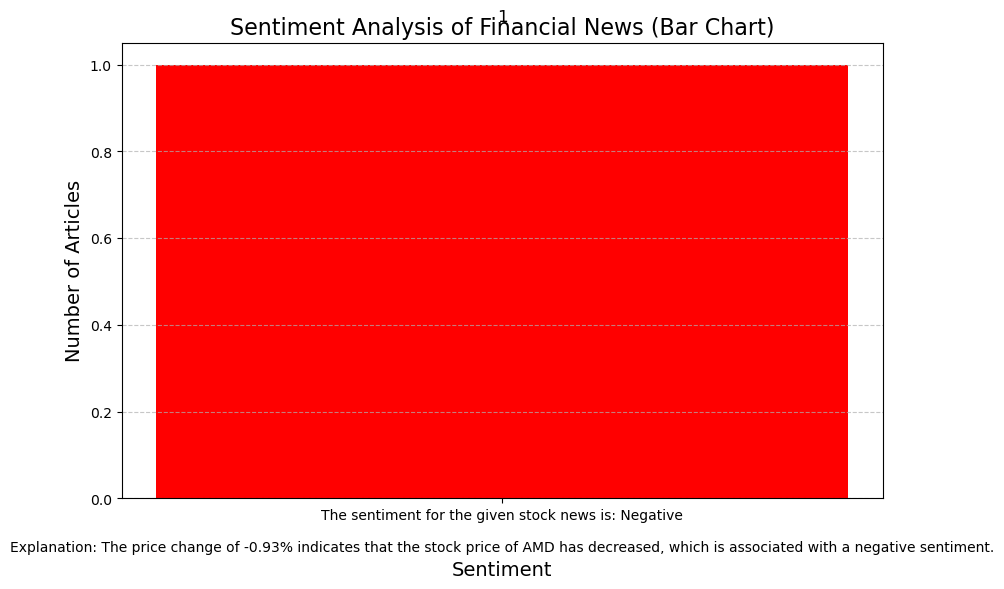

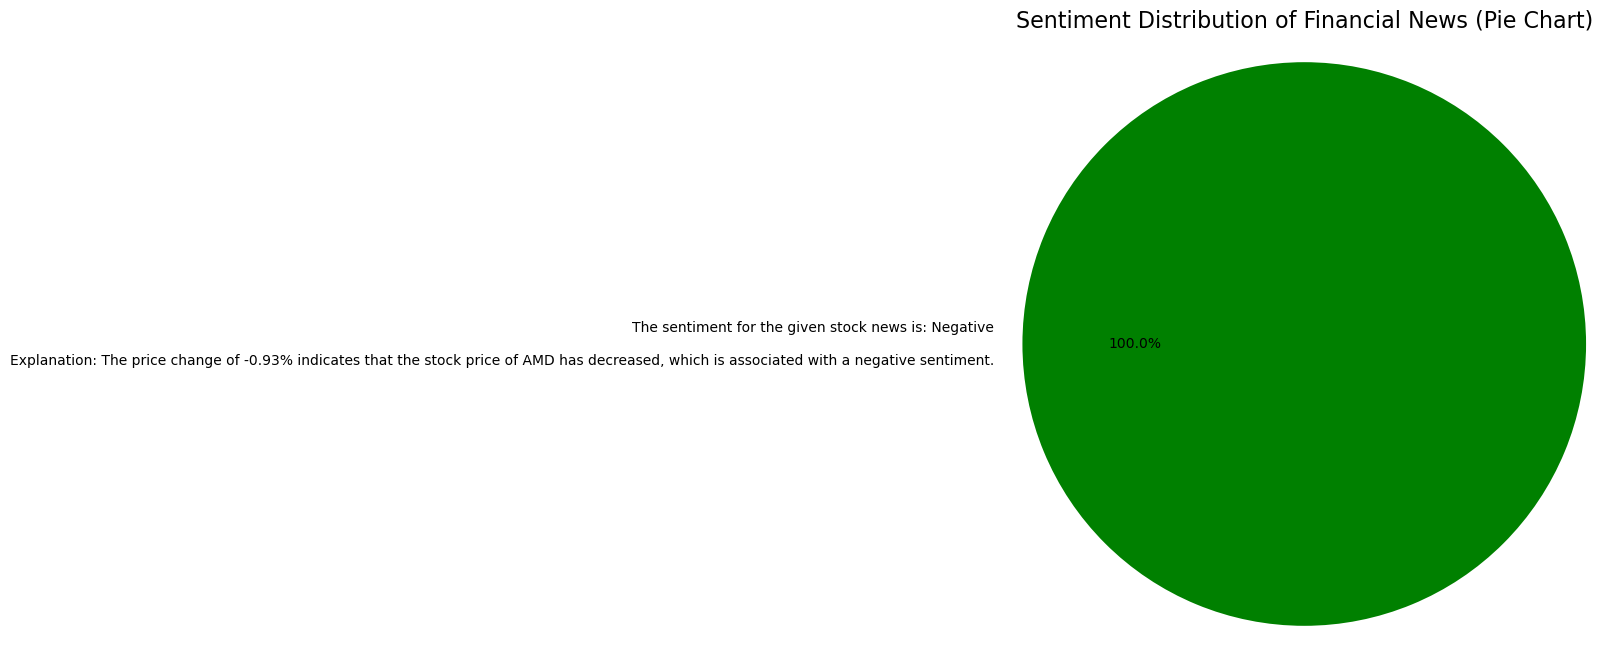

  Symbol               Name Percent Change  \
0    AMD  Adv Micro Devices         -0.93%   

                                           Sentiment  
0  The sentiment for the given stock news is: Neg...  


In [7]:
# Sentiment Analysis using Cerebras API and LLaMA 3.1

import requests
import pandas as pd
import matplotlib.pyplot as plt
import os
from cerebras.cloud.sdk import Cerebras

# Initialize Cerebras client
os.environ['CEREBRAS_API_KEY'] = 'csk-4nryfm65rjdf8e2vrmcx8ch3kw8n5v4wynpdd6e3rwmw9d3k'  # Replace with your actual API key
client = Cerebras(api_key=os.environ.get("CEREBRAS_API_KEY"))


# Step 1: Data Collection from Financial News
def fetch_news_data(api_url, headers, tickers):
    """
    Fetch financial news data from Yahoo Finance API, handle JSON responses gracefully,
    and filter for specific tickers (AMD, NFLX, ADBE).
    """
    response = requests.get(api_url, headers=headers)
    
    # Check if request was successful
    if response.status_code == 200:
        try:
            news_data = response.json()  # Parse JSON response
            print("Raw Response:", news_data)  # Inspect the full JSON response
            articles = news_data.get('body', [])  # Get articles from 'body'
            if len(articles) == 0:
                print("No articles found!")
            # Extract symbol and related information, filtering for specified tickers
            filtered_articles = [
                (article['symbol'], article['symbolName'], article['percentChange'])
                for article in articles
                if article['symbol'] in tickers
            ]
            return filtered_articles
        except ValueError as e:
            print(f"Error parsing JSON: {e}")
            return []
    else:
        print(f"Error fetching news: {response.status_code}")
        return []


# Example API for fetching news
financial_news_api_url = "https://yahoo-finance15.p.rapidapi.com/api/v1/markets/options/most-active?type=STOCKS"
headers = {
    'x-rapidapi-key': "69a7298d19msh6df706df60873e7p11a420jsn3319cdea9e0e",
    'x-rapidapi-host': "yahoo-finance15.p.rapidapi.com"
}

# Specify the tickers to filter for
filtered_tickers = ["AMD", "NFLX", "ADBE"]
news_articles = fetch_news_data(financial_news_api_url, headers, filtered_tickers)


def analyze_sentiment(text):
    """
    Function to analyze sentiment of a financial news article using Cerebras and LLaMA.
    """
    prompt = f"Determine the sentiment (positive, neutral, negative) for the following financial news: {text}"
    try:
        response = client.chat.completions.create(
            model="llama3.1-8b",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=50
        )

        # Print the entire response to inspect its structure
        print("Chat Completion Response:", response)

        # Access the generated text correctly
        sentiment = response.choices[0].message.content  # Use the correct attribute path
        return sentiment.strip()
    except Exception as e:
        print(f"Error during sentiment analysis: {e}")
        return "Neutral"  # Return neutral sentiment in case of an error


# Analyze sentiment for each article
news_with_sentiment = []
for symbol, name, percent_change in news_articles:
    sentiment = analyze_sentiment(f"Stock {name} ({symbol}) with a price change of {percent_change}")
    news_with_sentiment.append((symbol, name, percent_change, sentiment))

# Create DataFrame
df = pd.DataFrame(news_with_sentiment, columns=['Symbol', 'Name', 'Percent Change', 'Sentiment'])

# Count sentiments
sentiment_counts = df['Sentiment'].value_counts()

# Plot bar chart
plt.figure(figsize=(10, 6))
colors = ['green' if 'positive' in sentiment.lower() else 'red' if 'negative' in sentiment.lower() else 'blue' for sentiment in sentiment_counts.index]
bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=colors)

plt.title('Sentiment Analysis of Financial News (Bar Chart)', fontsize=16)
plt.xlabel('Sentiment', fontsize=14)
plt.ylabel('Number of Articles', fontsize=14)
plt.xticks(rotation=0)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval), ha='center', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, labels=sentiment_counts.index, colors=['green', 'red', 'blue'], autopct='%1.1f%%')
plt.title('Sentiment Distribution of Financial News (Pie Chart)', fontsize=16)
plt.axis('equal')  # Equal aspect ratio ensures pie is drawn as a circle.
plt.show()

# Display as table
print(df)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/aanyabhandari/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Raw Response: {'meta': {'version': 'v1.0', 'status': 200, 'copywrite': 'https://apicalls.io', 'count': 20, 'total': 500, 'page': 1}, 'body': [{'symbol': 'NVDA', 'symbolType': 1, 'symbolName': 'Nvidia Corp', 'hasOptions': 'Yes', 'lastPrice': '134.68', 'priceChange': '+0.26', 'percentChange': '+0.19%', 'optionsImpliedVolatilityRank1y': '48.89%', 'optionsTotalVolume': '1,971,754', 'optionsPutVolumePercent': '36.7%', 'optionsCallVolumePercent': '63.3%', 'optionsPutCallVolumeRatio': '0.58', 'tradeTime': '13:39 ET', 'symbolCode': 'STK'}, {'symbol': 'TSLA', 'symbolType': 1, 'symbolName': 'Tesla Inc', 'hasOptions': 'Yes', 'lastPrice': '337.71', 'priceChange': '-0.09', 'percentChange': '-0.03%', 'optionsImpliedVolatilityRank1y': '30.20%', 'optionsTotalVolume': '1,353,407', 'optionsPutVolumePercent': '46.2%', 'optionsCallVolumePercent': '53.8%', 'optionsPutCallVolumeRatio': '0.86', 'tradeTime': '13:39 ET', 'symbolCode': 'STK'}, {'symbol': 'PLTR', 'symbolType': 1, 'symbolName': 'Palantir Technolo

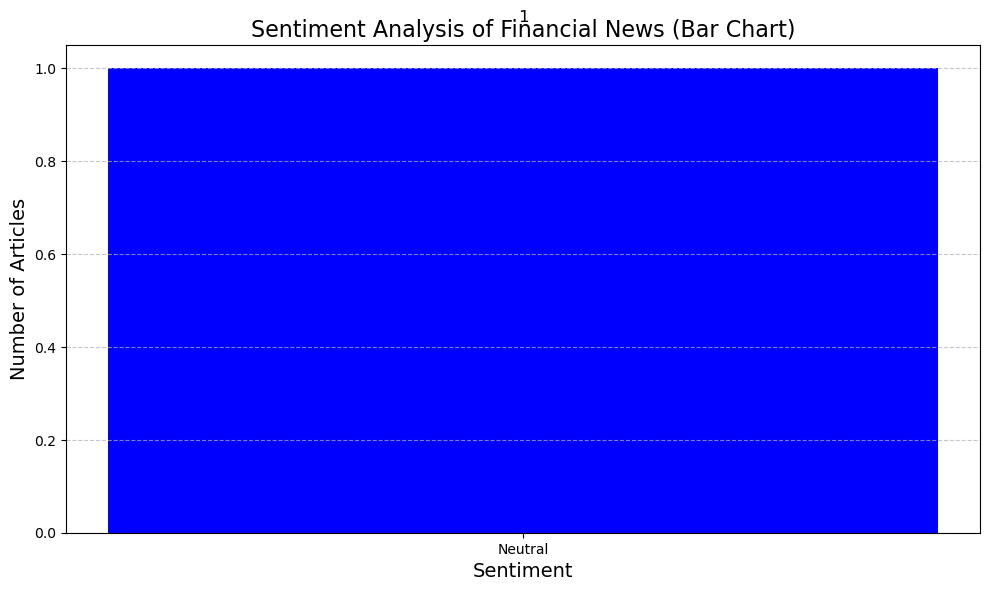

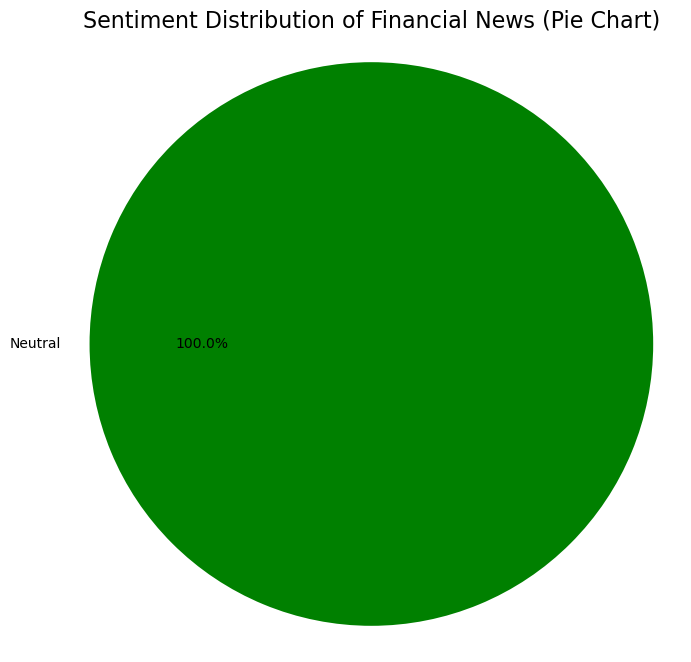

  Symbol               Name Percent Change  Sentiment_Score Sentiment
0    AMD  Adv Micro Devices         -0.93%              0.0   Neutral


In [8]:
# Sentiment Analysis using VADER

import requests
import pandas as pd
import matplotlib.pyplot as plt
import os
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon if you haven't already
try:
    nltk.download('vader_lexicon')
except LookupError:
    print("Downloading vader_lexicon failed. Ensure internet connection and try again.")
    raise  # Re-raise the exception to stop execution


# Step 1: Data Collection from Financial News
def fetch_news_data(api_url, headers, tickers):
    """
    Fetch financial news data from Yahoo Finance API, handle JSON responses gracefully,
    and filter for specific tickers (AMD, NFLX, ADBE).
    """
    response = requests.get(api_url, headers=headers)

    # Check if request was successful
    if response.status_code == 200:
        try:
            news_data = response.json()  # Parse JSON response
            print("Raw Response:", news_data)  # Inspect the full JSON response
            articles = news_data.get('body', [])  # Get articles from 'body'
            if len(articles) == 0:
                print("No articles found!")
            # Extract symbol and related information, filtering for specified tickers
            filtered_articles = [
                (article['symbol'], article['symbolName'], article['percentChange'])
                for article in articles
                if article['symbol'] in tickers
            ]
            return filtered_articles
        except ValueError as e:
            print(f"Error parsing JSON: {e}")
            return []
    else:
        print(f"Error fetching news: {response.status_code}")
        return []


# Example API for fetching news
financial_news_api_url = "https://yahoo-finance15.p.rapidapi.com/api/v1/markets/options/most-active?type=STOCKS"
headers = {
    'x-rapidapi-key': "69a7298d19msh6df706df60873e7p11a420jsn3319cdea9e0e",
    'x-rapidapi-host': "yahoo-finance15.p.rapidapi.com"
}

# Specify the tickers to filter for
filtered_tickers = ["AMD", "NFLX", "ADBE"]
news_articles = fetch_news_data(financial_news_api_url, headers, filtered_tickers)

def analyze_sentiment(text):
    """
    Function to analyze sentiment of a financial news article using VADER.
    """
    analyzer = SentimentIntensityAnalyzer()
    vs = analyzer.polarity_scores(text)
    return vs['compound']  # Returns a compound score between -1 and 1


# Analyze sentiment for each article
news_with_sentiment = []
for symbol, name, percent_change in news_articles:
    sentiment_score = analyze_sentiment(f"Stock {name} ({symbol}) with a price change of {percent_change}")
    news_with_sentiment.append((symbol, name, percent_change, sentiment_score))

# Create DataFrame
df = pd.DataFrame(news_with_sentiment, columns=['Symbol', 'Name', 'Percent Change', 'Sentiment_Score'])

# Define a function to categorize sentiment scores
def categorize_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

# Apply sentiment categorization
df['Sentiment'] = df['Sentiment_Score'].apply(categorize_sentiment)


# Count sentiments
sentiment_counts = df['Sentiment'].value_counts()

# Plot bar chart
plt.figure(figsize=(10, 6))
colors = ['green' if sentiment == 'Positive' else 'red' if sentiment == 'Negative' else 'blue' for sentiment in sentiment_counts.index]
bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=colors)

plt.title('Sentiment Analysis of Financial News (Bar Chart)', fontsize=16)
plt.xlabel('Sentiment', fontsize=14)
plt.ylabel('Number of Articles', fontsize=14)
plt.xticks(rotation=0)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval), ha='center', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, labels=sentiment_counts.index, colors=['green', 'red', 'blue'], autopct='%1.1f%%')
plt.title('Sentiment Distribution of Financial News (Pie Chart)', fontsize=16)
plt.axis('equal')  # Equal aspect ratio ensures pie is drawn as a circle.
plt.show()

# Display as table
print(df)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/aanyabhandari/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Raw Response: {'meta': {'version': 'v1.0', 'status': 200, 'copywrite': 'https://apicalls.io', 'count': 20, 'total': 500, 'page': 1}, 'body': [{'symbol': 'NVDA', 'symbolType': 1, 'symbolName': 'Nvidia Corp', 'hasOptions': 'Yes', 'lastPrice': '134.68', 'priceChange': '+0.26', 'percentChange': '+0.19%', 'optionsImpliedVolatilityRank1y': '48.89%', 'optionsTotalVolume': '1,971,754', 'optionsPutVolumePercent': '36.7%', 'optionsCallVolumePercent': '63.3%', 'optionsPutCallVolumeRatio': '0.58', 'tradeTime': '13:39 ET', 'symbolCode': 'STK'}, {'symbol': 'TSLA', 'symbolType': 1, 'symbolName': 'Tesla Inc', 'hasOptions': 'Yes', 'lastPrice': '337.71', 'priceChange': '-0.09', 'percentChange': '-0.03%', 'optionsImpliedVolatilityRank1y': '30.20%', 'optionsTotalVolume': '1,353,407', 'optionsPutVolumePercent': '46.2%', 'optionsCallVolumePercent': '53.8%', 'optionsPutCallVolumeRatio': '0.86', 'tradeTime': '13:39 ET', 'symbolCode': 'STK'}, {'symbol': 'PLTR', 'symbolType': 1, 'symbolName': 'Palantir Technolo

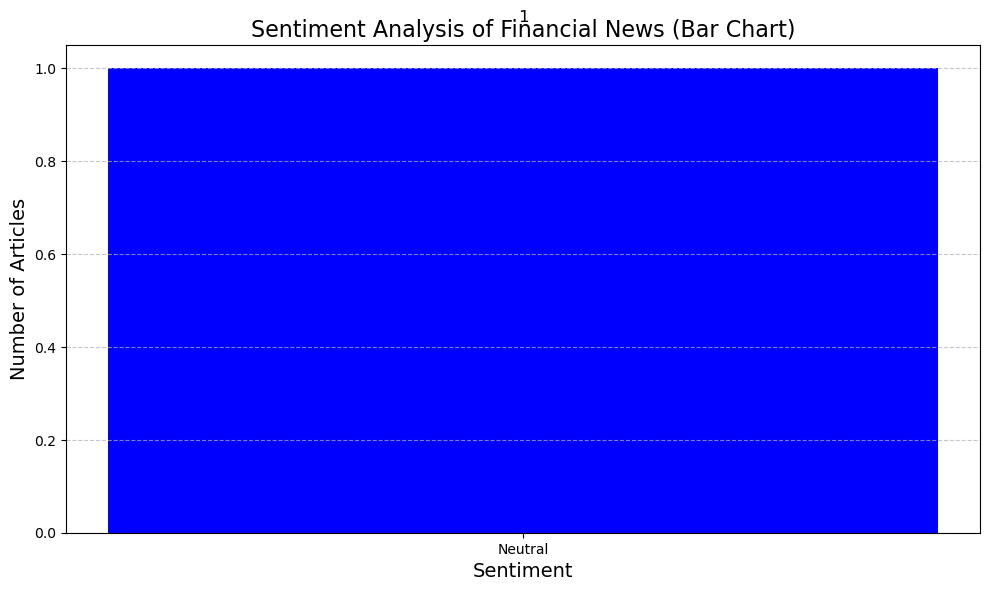

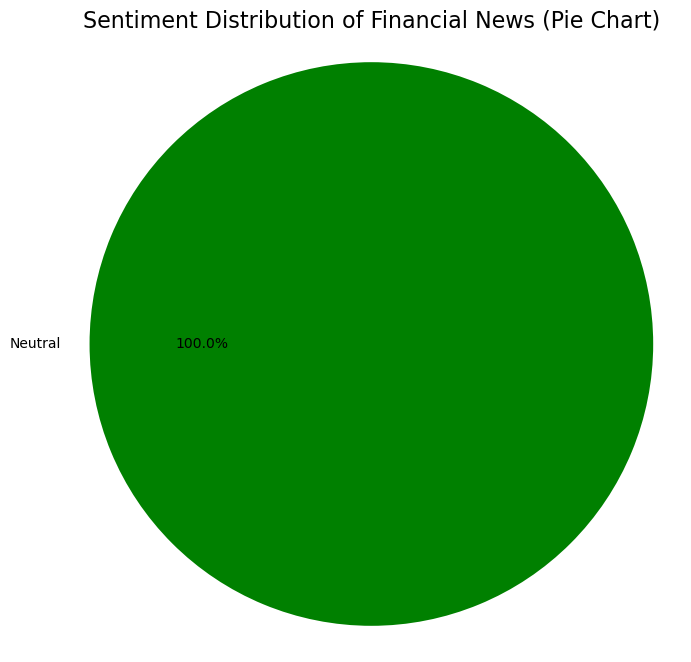

  Symbol               Name Percent Change  Sentiment_Score Sentiment
0    AMD  Adv Micro Devices         -0.93%              0.0   Neutral


In [9]:
# Sentiment Analysis using VADER

import requests
import pandas as pd
import matplotlib.pyplot as plt
import os
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon if you haven't already
try:
    nltk.download('vader_lexicon')
except LookupError:
    print("Downloading vader_lexicon failed. Ensure internet connection and try again.")
    raise  # Re-raise the exception to stop execution


# Step 1: Data Collection from Financial News
def fetch_news_data(api_url, headers, tickers):
    """
    Fetch financial news data from Yahoo Finance API, handle JSON responses gracefully,
    and filter for specific tickers (AMD, NFLX, ADBE).
    """
    response = requests.get(api_url, headers=headers)

    # Check if request was successful
    if response.status_code == 200:
        try:
            news_data = response.json()  # Parse JSON response
            print("Raw Response:", news_data)  # Inspect the full JSON response
            articles = news_data.get('body', [])  # Get articles from 'body'
            if len(articles) == 0:
                print("No articles found!")
            # Extract symbol and related information, filtering for specified tickers
            filtered_articles = [
                (article['symbol'], article['symbolName'], article['percentChange'])
                for article in articles
                if article['symbol'] in tickers
            ]
            return filtered_articles
        except ValueError as e:
            print(f"Error parsing JSON: {e}")
            return []
    else:
        print(f"Error fetching news: {response.status_code}")
        return []


# Example API for fetching news
financial_news_api_url = "https://yahoo-finance15.p.rapidapi.com/api/v1/markets/options/most-active?type=STOCKS"
headers = {
    'x-rapidapi-key': "69a7298d19msh6df706df60873e7p11a420jsn3319cdea9e0e",
    'x-rapidapi-host': "yahoo-finance15.p.rapidapi.com"
}

# Specify the tickers to filter for
filtered_tickers = ["AMD", "NFLX", "ADBE"]
news_articles = fetch_news_data(financial_news_api_url, headers, filtered_tickers)

def analyze_sentiment(text):
    """
    Function to analyze sentiment of a financial news article using VADER.
    """
    analyzer = SentimentIntensityAnalyzer()
    vs = analyzer.polarity_scores(text)
    return vs['compound']  # Returns a compound score between -1 and 1


# Analyze sentiment for each article
news_with_sentiment = []
for symbol, name, percent_change in news_articles:
    sentiment_score = analyze_sentiment(f"Stock {name} ({symbol}) with a price change of {percent_change}")
    news_with_sentiment.append((symbol, name, percent_change, sentiment_score))

# Create DataFrame
df = pd.DataFrame(news_with_sentiment, columns=['Symbol', 'Name', 'Percent Change', 'Sentiment_Score'])

# Define a function to categorize sentiment scores
def categorize_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

# Apply sentiment categorization
df['Sentiment'] = df['Sentiment_Score'].apply(categorize_sentiment)


# Count sentiments
sentiment_counts = df['Sentiment'].value_counts()

# Plot bar chart
plt.figure(figsize=(10, 6))
colors = ['green' if sentiment == 'Positive' else 'red' if sentiment == 'Negative' else 'blue' for sentiment in sentiment_counts.index]
bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=colors)

plt.title('Sentiment Analysis of Financial News (Bar Chart)', fontsize=16)
plt.xlabel('Sentiment', fontsize=14)
plt.ylabel('Number of Articles', fontsize=14)
plt.xticks(rotation=0)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval), ha='center', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, labels=sentiment_counts.index, colors=['green', 'red', 'blue'], autopct='%1.1f%%')
plt.title('Sentiment Distribution of Financial News (Pie Chart)', fontsize=16)
plt.axis('equal')  # Equal aspect ratio ensures pie is drawn as a circle.
plt.show()

# Display as table
print(df)